In [16]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import VarianceThreshold

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [17]:
try:
    df = pd.read_csv('/content/optdigits.csv')
    print('Dataset loaded from /content/optdigits.csv')

except FileNotFoundError:
    digits = load_digits(as_frame=True)
    df = digits.frame.copy()

    df.rename(columns={'target': 'digit'}, inplace=True)

    print('Built-in sklearn digits dataset loaded as fallback')

df.head()

Built-in sklearn digits dataset loaded as fallback


,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,...,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7,digit
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0,1
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0,2
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0,3
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0,4


In [18]:
print('Shape of dataset:', df.shape)

print('\nDataset information:')
df.info()

print('\nMissing values:')
print(df.isnull().sum().head())

Shape of dataset: (1797, 65)

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1797 entries, 0 to 1796
Data columns (total 65 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pixel_0_0  1797 non-null   float64
 1   pixel_0_1  1797 non-null   float64
 2   pixel_0_2  1797 non-null   float64
 3   pixel_0_3  1797 non-null   float64
 4   pixel_0_4  1797 non-null   float64
 5   pixel_0_5  1797 non-null   float64
 6   pixel_0_6  1797 non-null   float64
 7   pixel_0_7  1797 non-null   float64
 8   pixel_1_0  1797 non-null   float64
 9   pixel_1_1  1797 non-null   float64
 10  pixel_1_2  1797 non-null   float64
 11  pixel_1_3  1797 non-null   float64
 12  pixel_1_4  1797 non-null   float64
 13  pixel_1_5  1797 non-null   float64
 14  pixel_1_6  1797 non-null   float64
 15  pixel_1_7  1797 non-null   float64
 16  pixel_2_0  1797 non-null   float64
 17  pixel_2_1  1797 non-null   float64
 18  pixel_2_2  1797 non-null   float64
 1

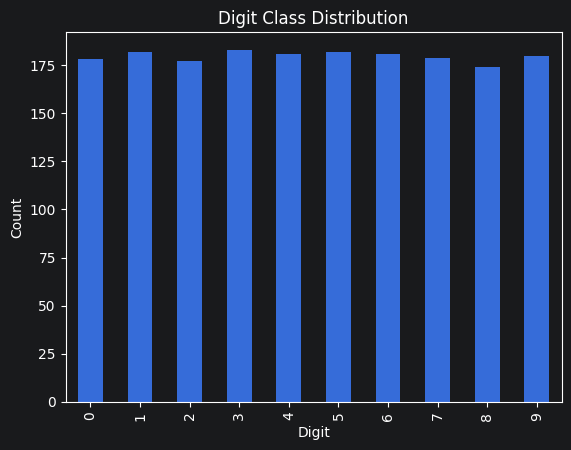

In [19]:
df['digit'].value_counts().sort_index().plot(kind='bar')

plt.title('Digit Class Distribution')
plt.xlabel('Digit')
plt.ylabel('Count')

plt.show()

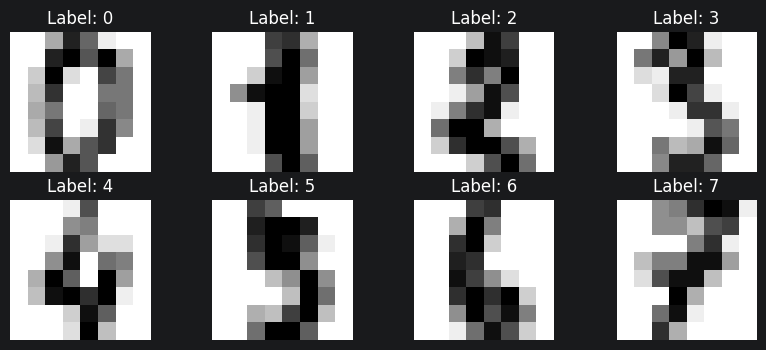

In [20]:
digits = load_digits()

fig, axes = plt.subplots(2, 4, figsize=(10, 4))

for ax, image, label in zip(axes.ravel(), digits.images[:8], digits.target[:8]):
    ax.imshow(image, cmap='gray_r')
    ax.set_title(f'Label: {label}')
    ax.axis('off')

plt.show()

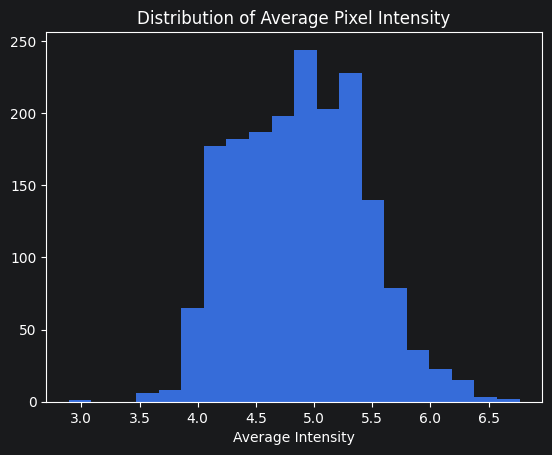

In [21]:
avg_intensity = df.drop(columns=['digit']).mean(axis=1)

plt.hist(avg_intensity, bins=20)

plt.title('Distribution of Average Pixel Intensity')
plt.xlabel('Average Intensity')

plt.show()

In [22]:
X = df.drop(columns=['digit'])
y = df['digit']

imputer = SimpleImputer(strategy='median')

X = imputer.fit_transform(X)

print('Missing values handled successfully.')

Missing values handled successfully.


In [23]:
print('Data type of X:', type(X))
print('Feature matrix shape:', X.shape)

Data type of X: <class 'numpy.ndarray'>
Feature matrix shape: (1797, 64)


In [24]:
selector = VarianceThreshold(threshold=0.0)

X_selected = selector.fit_transform(X)

print('Original shape:', X.shape)
print('Shape after feature selection:', X_selected.shape)

Original shape: (1797, 64)
Shape after feature selection: (1797, 61)


In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X_selected,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [26]:
model = RandomForestClassifier(n_estimators=200, random_state=42)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [27]:
accuracy = accuracy_score(y_test, y_pred)

cm = confusion_matrix(y_test, y_pred)

report = classification_report(y_test, y_pred)

print('Accuracy:', accuracy)

print('\nConfusion Matrix:\n', cm)

print('\nClassification Report:\n', report)

Accuracy: 0.9722222222222222

Confusion Matrix:
 [[35  0  0  0  1  0  0  0  0  0]
 [ 0 36  0  0  0  0  0  0  0  0]
 [ 1  0 34  0  0  0  0  0  0  0]
 [ 0  0  0 37  0  0  0  0  0  0]
 [ 0  0  0  0 36  0  0  0  0  0]
 [ 0  0  0  0  0 37  0  0  0  0]
 [ 0  0  0  0  0  0 35  0  1  0]
 [ 0  0  0  0  0  0  0 36  0  0]
 [ 0  3  0  0  0  0  0  1 31  0]
 [ 0  0  0  1  0  0  0  1  1 33]]

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.97      0.97        36
           1       0.92      1.00      0.96        36
           2       1.00      0.97      0.99        35
           3       0.97      1.00      0.99        37
           4       0.97      1.00      0.99        36
           5       1.00      1.00      1.00        37
           6       1.00      0.97      0.99        36
           7       0.95      1.00      0.97        36
           8       0.94      0.89      0.91        35
           9       1.00      0.92      0.96        36


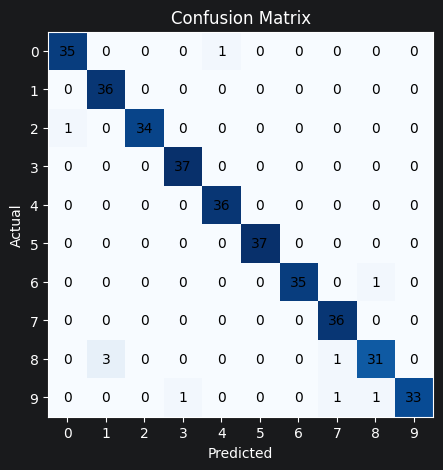

In [28]:
plt.figure(figsize=(7, 5))

plt.imshow(cm, cmap='Blues')

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j],
                 ha='center', va='center',
                 color='black')

plt.xticks(range(cm.shape[1]))
plt.yticks(range(cm.shape[0]))

plt.show()

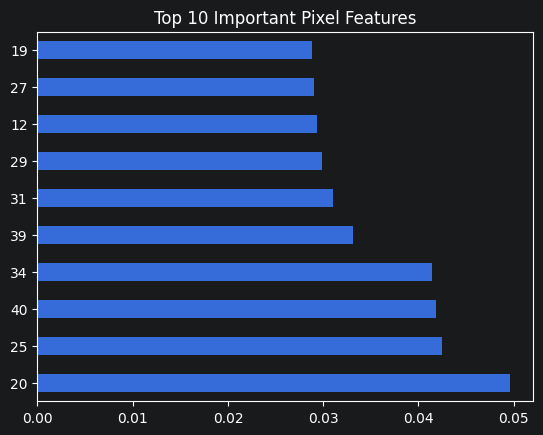

In [29]:
importances = pd.Series(model.feature_importances_).sort_values(ascending=False).head(10)

importances.plot(kind='barh')

plt.title('Top 10 Important Pixel Features')

plt.show()